# Differential correlation — DGCA

Classical differential analysis (`metabol.differential`) asks *which
metabolites change in abundance?* Differential **correlation** asks a
complementary question: *which metabolite–metabolite relationships
change between conditions?* Two metabolites might have identical mean
levels in both groups yet be tightly co-regulated in one and
uncorrelated in the other — evidence for a rewired pathway.

**`ov.metabol.dgca`** implements DGCA (McKenzie et al., *BMC
Genomics* 2016): Fisher-z transformation of each pair's correlation
in each condition, z-test on the difference, BH FDR, and a
categorical *DC class* label (`+/+`, `+/0`, `+/-`, …).

We use the **Cachexia** dataset — 77 urinary metabolomes labelled
`cachexic` vs `control` (47 vs 30).


## 0 — Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import omicverse as ov

csv_path = ov.datasets.download_data(
    url='https://rest.xialab.ca/api/download/metaboanalyst/human_cachexia.csv',
    file_path='human_cachexia.csv',
    dir='metabol_demo',
)
adata = ov.metabol.read_metaboanalyst(csv_path, group_col='Muscle loss')
adata = ov.metabol.impute(adata, method='qrilc', seed=0)
adata = ov.metabol.normalize(adata, method='pqn')
adata = ov.metabol.transform(adata, method='log')
adata


/home/users/steorra/miniforge3/envs/omicverse/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_loom from `anndata` is deprecated. Import anndata.io.read_loom instead.
  warnings.warn(msg, FutureWarning)


🔍 Downloading data to metabol_demo/human_cachexia.csv
⚠️ File metabol_demo/human_cachexia.csv already exists


AnnData object with n_obs × n_vars = 77 × 63
    obs: 'group'
    var: 'missing_frac'
    uns: 'metabol'
    layers: 'raw'

## 1 — Run DGCA

For 63 metabolites we get `63*62/2 = 1953` pairs. Use Spearman for
metabolomics (heavy-tailed distributions) and threshold |r|≥0.3 for
class labels (the default, matching MetaboAnalyst's network module).


In [2]:
dc = ov.metabol.dgca(
    adata,
    group_col='group',
    group_a='cachexic', group_b='control',
    method='spearman',
    abs_r_threshold=0.3,
)
print(f'{len(dc)} pairs tested')
dc.head(15)


1953 pairs tested


               feature_a            feature_b       r_a       r_b    z_diff  \
0                Citrate              Glycine  0.351989  0.856285 -3.728665   
1          Dimethylamine            Succinate  0.450278 -0.410456  3.768224   
2                Lactate              Taurine  0.078978 -0.713014  3.977756   
3         2-Oxoglutarate            Glutamine -0.019832  0.666741 -3.373402   
4       3-Indoxylsulfate       Guanidoacetate  0.296369 -0.472303  3.348357   
5              Histidine         Trigonelline  0.209644 -0.531924  3.295424   
6         Guanidoacetate  tau-Methylhistidine  0.346438 -0.407341  3.247102   
7                Acetone             Tyrosine  0.286193 -0.421580  3.043459   
8                Betaine         Ethanolamine -0.257285  0.450945 -3.064152   
9            Methylamine      Methylguanidine  0.272036 -0.434483  3.045276   
10          Ethanolamine        cis-Aconitate  0.463344 -0.228921  3.004948   
11               Alanine             Tyrosine  0.065

## 2 — DC class distribution

Each pair gets a two-symbol label `A/B` where `+/-/0` summarise the
correlation strength in groups cachexic (`A`) and control (`B`):


In [3]:
class_counts = dc['dc_class'].value_counts()
class_counts


dc_class
0/0    1444
0/-     173
0/+     143
-/0      71
+/0      63
+/+      35
-/-      21
+/-       3
Name: count, dtype: int64

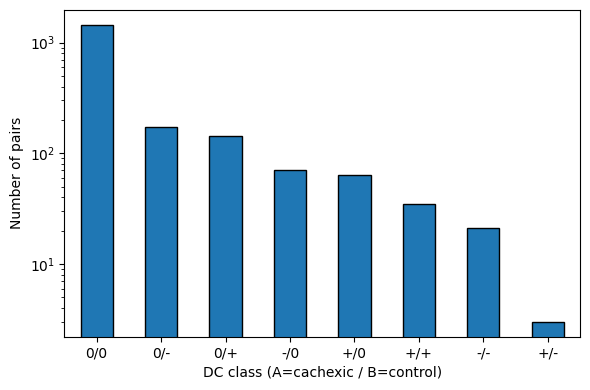

In [4]:
fig, ax = plt.subplots(figsize=(6, 4))
class_counts.plot.bar(ax=ax, color='C0', edgecolor='k')
ax.set_ylabel('Number of pairs')
ax.set_xlabel('DC class (A=cachexic / B=control)')
ax.set_yscale('log')
plt.xticks(rotation=0)
fig.tight_layout()
plt.show()


## 3 — Top rewired pairs

Sort by |z_diff| and inspect the most differentially correlated pairs.
Cachexia (77 samples) has limited power for pairwise inference — with
BH FDR at 5% only strong effects survive; we therefore rank by effect
size rather than filter on ``padj`` so the notebook illustrates the
API regardless.


In [5]:
dc_top = dc.copy()
dc_top['abs_z'] = dc_top['z_diff'].abs()
top = dc_top.sort_values('abs_z', ascending=False).head(15)
top[['feature_a', 'feature_b', 'r_a', 'r_b', 'z_diff', 'padj', 'dc_class']]


           feature_a            feature_b       r_a       r_b    z_diff  \
2            Lactate              Taurine  0.078978 -0.713014  3.977756   
1      Dimethylamine            Succinate  0.450278 -0.410456  3.768224   
0            Citrate              Glycine  0.351989  0.856285 -3.728665   
3     2-Oxoglutarate            Glutamine -0.019832  0.666741 -3.373402   
4   3-Indoxylsulfate       Guanidoacetate  0.296369 -0.472303  3.348357   
5          Histidine         Trigonelline  0.209644 -0.531924  3.295424   
6     Guanidoacetate  tau-Methylhistidine  0.346438 -0.407341  3.247102   
8            Betaine         Ethanolamine -0.257285  0.450945 -3.064152   
9        Methylamine      Methylguanidine  0.272036 -0.434483  3.045276   
7            Acetone             Tyrosine  0.286193 -0.421580  3.043459   
10      Ethanolamine        cis-Aconitate  0.463344 -0.228921  3.004948   
13           Glucose            Histidine  0.074931 -0.568854  2.948854   
11           Alanine     

## 4 — Visualise one rewired pair

Pick the top pair and show the raw correlation in each group on a
scatter plot:


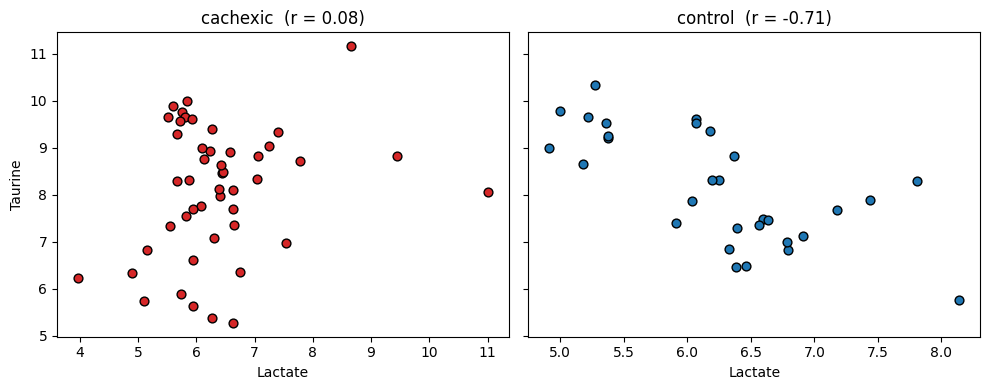

In [6]:
top_row = top.iloc[0]
fa, fb = top_row['feature_a'], top_row['feature_b']
idx_a = list(adata.var_names).index(fa)
idx_b = list(adata.var_names).index(fb)

groups = adata.obs['group'].astype(str).to_numpy()
X = np.asarray(adata.X)

fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)
for ax, label, colour in zip(axes, ['cachexic', 'control'], ['C3', 'C0']):
    mask = groups == label
    ax.scatter(X[mask, idx_a], X[mask, idx_b], color=colour,
               edgecolor='k', s=40)
    ax.set_xlabel(fa)
    ax.set_title(f'{label}  (r = {(top_row["r_a"] if label == "cachexic" else top_row["r_b"]):.2f})')
axes[0].set_ylabel(fb)
fig.tight_layout()
plt.show()


## 5 — Rewired correlation network

Build a small NetworkX graph of the top-rewired pairs coloured by DC
class:


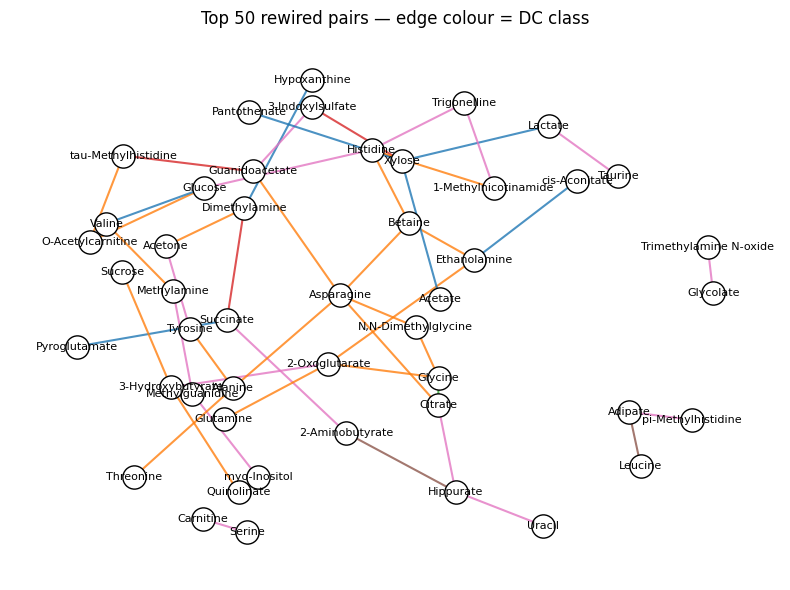

In [7]:
import networkx as nx

top50 = dc_top.sort_values('abs_z', ascending=False).head(50)
G = nx.Graph()
class_colour = {'+/+': 'C2', '-/-': 'C4', '+/-': 'C3', '-/+': 'C3',
                '+/0': 'C0', '0/+': 'C1', '-/0': 'C5', '0/-': 'C6', '0/0': 'lightgray'}
for _, r in top50.iterrows():
    G.add_edge(r['feature_a'], r['feature_b'],
               weight=abs(r['z_diff']),
               color=class_colour.get(r['dc_class'], 'gray'))
pos = nx.spring_layout(G, seed=0, k=0.7)
edge_colors = [G[u][v]['color'] for u, v in G.edges()]
fig, ax = plt.subplots(figsize=(8, 6))
nx.draw_networkx_edges(G, pos, edge_color=edge_colors, width=1.5, alpha=0.8)
nx.draw_networkx_nodes(G, pos, node_size=280, node_color='white',
                        edgecolors='k', ax=ax)
nx.draw_networkx_labels(G, pos, font_size=8, ax=ax)
ax.set_title('Top 50 rewired pairs — edge colour = DC class')
ax.axis('off')
fig.tight_layout()
plt.show()


## 6 — Static per-condition networks (`corr_network`)

DGCA compares conditions. Sometimes you want the **static** network
in each condition on its own — a co-regulation backbone you can
visualise, annotate with pathways, or export to Cytoscape.

`ov.metabol.corr_network` returns a filtered edge list (|r| ≥
threshold, padj < α) for a single condition. Below we build networks
separately for cachexic and control and compare their size / overlap:


In [8]:
edges_ca = ov.metabol.corr_network(
    adata,
    group_col='group', group='cachexic',
    method='spearman',
    abs_r_threshold=0.5, padj_threshold=0.05,
)
edges_ct = ov.metabol.corr_network(
    adata,
    group_col='group', group='control',
    method='spearman',
    abs_r_threshold=0.5, padj_threshold=0.05,
)
print(f'cachexic network : {len(edges_ca)} edges on {edges_ca.attrs["n_samples"]} samples')
print(f'control  network : {len(edges_ct)} edges on {edges_ct.attrs["n_samples"]} samples')

def pair_key(row):
    return frozenset((row['feature_a'], row['feature_b']))

ca_pairs = set(edges_ca.apply(pair_key, axis=1))
ct_pairs = set(edges_ct.apply(pair_key, axis=1))
print(f'shared edges     : {len(ca_pairs & ct_pairs)}')
print(f'cachexic-only    : {len(ca_pairs - ct_pairs)}')
print(f'control-only     : {len(ct_pairs - ca_pairs)}')


cachexic network : 16 edges on 47 samples
control  network : 15 edges on 30 samples
shared edges     : 0
cachexic-only    : 16
control-only     : 15


### Top edges in the cachexic network

In [9]:
edges_ca.head(10)


            feature_a               feature_b         r        pvalue  \
0          Creatinine           Dimethylamine  0.768270  1.583932e-11   
1           Carnitine       O-Acetylcarnitine  0.662812  1.209255e-07   
2             Glucose                 Lactate  0.609389  2.652975e-06   
3             Acetate               Succinate  0.606614  3.059246e-06   
4       Dimethylamine  Trimethylamine N-oxide  0.569380  1.794035e-05   
5       Dimethylamine           Pyroglutamate  0.564870  2.185967e-05   
6      2-Oxoglutarate                 Acetate -0.561748  2.501540e-05   
7          Creatinine            Hypoxanthine  0.550994  3.933656e-05   
8  pi-Methylhistidine     tau-Methylhistidine  0.526364  1.039705e-04   
9             Acetate         Methylguanidine -0.520467  1.295807e-04   

           padj  
0  3.093420e-08  
1  1.180838e-04  
2  1.493677e-03  
3  1.493677e-03  
4  6.979296e-03  
5  6.979296e-03  
6  6.979296e-03  
7  9.603037e-03  
8  2.256160e-02  
9  2.530712e-02 

### Venn-like side-by-side

Plot the two networks with a common layout (union of nodes) so
differences in *who connects to whom* become obvious.


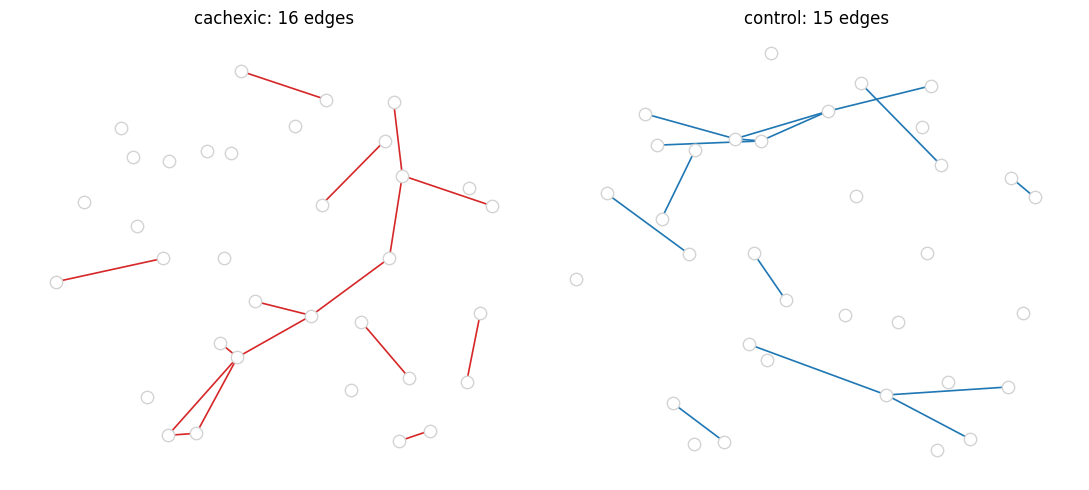

In [10]:
import networkx as nx

all_nodes = list(set(edges_ca['feature_a']) | set(edges_ca['feature_b'])
                 | set(edges_ct['feature_a']) | set(edges_ct['feature_b']))
Gu = nx.Graph()
Gu.add_nodes_from(all_nodes)
for df in (edges_ca, edges_ct):
    for _, r in df.iterrows():
        Gu.add_edge(r['feature_a'], r['feature_b'])
pos = nx.spring_layout(Gu, seed=0, k=0.6)

fig, axes = plt.subplots(1, 2, figsize=(11, 5))
for ax, edges, title, colour in zip(
        axes, [edges_ca, edges_ct],
        ['cachexic', 'control'],
        ['C3', 'C0']):
    G = nx.from_pandas_edgelist(edges,
                                 source='feature_a', target='feature_b',
                                 edge_attr='r')
    nx.draw_networkx_nodes(Gu, pos, node_size=80,
                            node_color='white', edgecolors='lightgray', ax=ax)
    nx.draw_networkx_edges(G, pos, edge_color=colour, width=1.2, ax=ax)
    ax.set_title(f'{title}: {G.number_of_edges()} edges')
    ax.axis('off')
fig.tight_layout()
plt.show()


## Takeaways

- DGCA surfaces relationships that `metabol.differential` misses.
- The **class labels** (`+/+`, `+/0`, `+/-`…) give an interpretable
  summary: `+/0` = "correlation gained in A", `+/-` = "inversion".
- For large panels (`p > 500`) restrict with `features=<top-N by
  univariate AUC or VIP>` to keep the O(p²) output manageable.

DGCA pairs naturally with ASCA + biomarker panels: they answer
different questions about the same data.
